In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt


In [3]:
pd.set_option('display.max_columns', 350)
pd.set_option('display.max_rows', 350)

In [4]:
runs_folders = [
    "/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations/runs-rebuttal",
]

base_dir = Path("/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations")


In [5]:
all_runs = []
for runs_folder in runs_folders:
    runs_path = Path(runs_folder)
    target_runs = list(runs_path.glob('**/run_*'))
    
    for run_path in target_runs:
        if not run_path.is_dir():
            continue
        # skip checkpoint subdirs
        if 'checkpoint' in str(run_path):
            continue
            
        run_stats = {}
        run_stats['run_path'] = str(run_path)
        run_stats['runs_folder'] = runs_path.name
        run_stats['run_name'] = run_path.parent.name
        run_stats['task_name'] = run_path.parent.parent.name
        run_stats['run_id'] = int(run_path.name.split('_')[1])
        
        config_path = run_path / 'config.json'
        if config_path.exists():
            cli_args = json.load(open(config_path))['cli_args']
            run_stats.update(cli_args)
        
        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path))
            run_stats.update(results)
        else:
            run_stats['eval_exact_match'] = np.nan
            run_stats['eval_token_accuracy'] = np.nan
        all_runs.append(run_stats)
df = pd.DataFrame(all_runs)
print(f"Total runs: {len(df)}")
print(f"Columns: {list(df.columns)}")
# df

Total runs: 620
Columns: ['run_path', 'runs_folder', 'run_name', 'task_name', 'run_id', 'exp_path', 'per_device_batch_size', 'data_path', 'tokenizer_path', 'gradient_accumulation_steps', 'total_batch_size', 'metric_for_best_model', 'warmup_steps', 'max_steps', 'logging_steps', 'eval_steps', 'weight_decay', 'learning_rate', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'lr_scheduler_type', 'early_stopping_patience', 'seed', 'base_model', 'pretrained_model', 'n_layer', 'n_head', 'n_embd', 'state_size', 'conv_kernel', 'max_position_embeddings', 'max_input_length', 'attn_implementation', 'n_pairs', 'n_keys', 'n_values', 'overwrite_output_dir', 'do_eval_only', 'epoch', 'eval_exact_match', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_token_accuracy', 'num_input_tokens_seen', 'patience']


In [6]:
import re

def parse_run_name(run_name):
    info = {}
    
    m = re.match(r'^(.+?)_L(\d+)H(\d+)D(\d+)(.*)', run_name)
    if not m:
        return info
    
    info['model'] = m.group(1)
    info['L'] = int(m.group(2))
    info['H'] = int(m.group(3))
    info['D'] = int(m.group(4))
    rest = m.group(5)
    
    mem_match = re.search(r'_mem(\d+)', rest)
    if mem_match:
        info['mem'] = int(mem_match.group(1))
    
    seg_match = re.search(r'-(\d+x\d+)', rest)
    if seg_match:
        info['segment'] = seg_match.group(1)
    
    return info

parsed = df['run_name'].apply(parse_run_name).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

In [7]:
df.shape

(620, 48)

In [8]:
# df['eval_exact_match'] = df['eval_exact_match'].fillna(df['eval_exact_match_base'])
df = df.dropna(subset=['eval_exact_match'])

# df.mem = df.mem.fillna(0).astype(int)
# df.segment = df.segment.fillna('1x' + df.

df['modification'] = ''
df.loc[df.max_steps == 200000, 'modification'] += ' 2x steps'

df['n_pairs'] = df.task_name.apply(lambda x: int(x[1:].split('-')[0]))

In [9]:
df.shape

(233, 49)

In [10]:
# df[df.run_path.apply(lambda x: 'gating-v2' in x)][['run_path', 'run_name', 'eval_exact_match']]

In [15]:
# df.exp_path.unique().tolist()


In [16]:
# df[df.exp_path.apply(lambda x: '1L-1W' in x)]

In [17]:
import re

def extract_params_from_run_path(run_path):
    """
    Extract parameters from run_path string.
    Example:
      N8-K2V2-V62_1M/mamba2_L4D64_ss16_ck4_bs_64_lr_1e-03_b2_0.999
      will extract:
        n_pairs=8, k=2, v=2, Vocab=62, model=mamba2, layers=4,
        dim=64, ss=16, ck=4, bs=64, lr=1e-03, b2=0.999
    """
    params = {}

    # Match dataset info: N8-K2V2-V62_1M
    ds = re.search(r'N(\d+)-K(\d+)V(\d+)-V(\d+)_1M', run_path)
    if ds:
        params['n_pairs'] = int(ds.group(1))
        params['k'] = int(ds.group(2))
        params['v'] = int(ds.group(3))
        params['Vocab'] = int(ds.group(4))

    # Match model and hyperparameters, e.g. mamba2_L4D64_ss16_ck4_bs_64_lr_1e-03_b2_0.999
    m = re.search(
        r'/([\w\-]+)_L(\d+)D(\d+)_ss(\d+)_ck(\d+)_bs_(\d+)_lr_([\de\.-]+)(?:_b2_([\d\.]+))?', run_path
    )
    if m:
        params['model'] = m.group(1)
        params['layers'] = int(m.group(2))
        params['dim'] = int(m.group(3))
        params['ss'] = int(m.group(4))
        params['ck'] = int(m.group(5))
        params['bs'] = int(m.group(6))
        params['lr'] = m.group(7)
        if m.group(8):
            params['b2'] = float(m.group(8))

    return params

# Example: extract all params from unique run_paths and create a DataFrame
param_list = [extract_params_from_run_path(x) for x in df.run_path]
params_df = pd.DataFrame(param_list)
for col in params_df.columns:
    df[col] = params_df[col]

In [18]:
params_df.head()

,n_pairs,k,v,Vocab,model,layers,dim,ss,ck,bs,lr,b2
0,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
1,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
2,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
3,8,2,2,62,mamba2,1,64,4,4,64,1e-03,0.999
4,8,2,2,62,mamba2,1,64,4,4,64,1e-03,0.999


In [21]:
group_cols = [
    'task_name',              # or ['n_pairs', 'n_keys', 'n_values'] if you prefer explicit task identity
    'base_model',
    'n_layer',
    'n_embd',
    'state_size',
    'conv_kernel',
    # 'per_device_batch_size',
    'learning_rate',
    # 'adam_beta2',
    # 'max_steps',              # better than grouping by the derived 'modification' label
]

In [22]:
# debug_cols = ['n_pairs', 'model', 'layers', 'dim', 'ss', 'ck', 'bs', 'lr', 'b2']
# df[df[debug_cols].isna().any(axis=1)][
#     ['run_path', 'run_name', 'task_name', 'base_model', 'n_layer', 'n_embd',
#      'state_size', 'conv_kernel', 'per_device_batch_size',
#      'learning_rate', 'adam_beta2', 'max_steps', 'eval_exact_match']
# ].sort_values(['task_name', 'run_name'])

In [23]:
# debug_cols = ['n_pairs', 'model', 'layers', 'dim', 'ss', 'ck', 'bs', 'lr', 'b2']
# df[df[debug_cols].isna().any(axis=1)][
#     ['run_path', 'run_name', 'task_name', 'base_model', 'n_layer', 'n_embd',
#      'state_size', 'conv_kernel', 'per_device_batch_size',
#      'learning_rate', 'adam_beta2', 'max_steps', 'eval_exact_match']
# ].sort_values(['task_name', 'run_name'])

In [24]:
grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
)
grouped

avg_em  \
task_name       base_model      n_layer n_embd state_size conv_kernel learning_rate           
N16-K2V2-V62_1M mamba2          1       64     4          4           0.001            9.04   
                                        128    2          2           0.001            2.69   
                                                          4           0.001            2.95   
                                               4          2           0.001            4.85   
                                                          4           0.001            8.98   
                                               16         2           0.001            6.25   
                                                          4           0.001           34.33   
                                        256    4          4           0.001            6.61   
                                2       32     32         2           0.001            6.66   
                                                          4           0.001           64.23   
                                        64     2          2           0.001            5.77   
                                               32         2           0.001           32.49   
                                                          4           0.001           97.65   
                                        128    2          2           0.001            6.35   
                                                          4           0.001            8.55   
                                               4          2           0.001           10.25   
                                                          4           0.001           58.79   
                                               16         2           0.001           19.31   
                                                          4           0.001           35.43   
                                               32         2           0.001           54.25   
                                                          4           0.001           99.38   
                                        256    2          2           0.001            2.84   
                                4       64     4          4           0.001           47.01   
                                               16         4           0.001           98.40   
                                        256    4          4           0.001           78.41   
                                               16         4           0.001           91.27   
N32-K2V2-V62_1M mamba2          1       64     4          4           0.001            2.21   
                                        128    2          2           0.001            1.17   
                                                          4           0.001            2.11   
                                               4          2           0.001            2.18   
                                                          4           0.001            4.78   
                                               16         2           0.001            3.25   
                                                          4           0.001           35.79   
                                        256    4          4           0.001            8.58   
                                2       32     32         2           0.001            4.27   
                                                          4           0.001           41.75   
                                        64     2          2           0.001            0.77   
                                               32         2           0.001            3.55   
                                                          4           0.001           47.53   
                                        128    2          2           0.001            2.67   
                                                          4           0.001           15.44   


In [29]:
from pathlib import Path
import os
import shutil

base = Path('/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations/runs-rebuttal')
for run_path in sorted(base.glob('**/run_*')):
    if not run_path.is_dir():
        continue
    if 'checkpoint' in str(run_path):
        continue
    has_checkpoint = any(run_path.glob('checkpoint*'))
    has_logs = (run_path / 'logs').exists()
    has_results = (run_path / 'all_results.json').exists()
    if not has_checkpoint and not has_logs:
        print(run_path)
        # try:
        #     os.rmdir(run_path)
        # except OSError as e:
        #     # Directory not empty; try to remove all contents first
        #     print(f"Could not remove {run_path} with os.rmdir, trying shutil.rmtree instead.")
        #     shutil.rmtree(run_path)
 

/workspace-SR006.nfs2/bulatov/rmt/test-time/compressing-associations/runs-rebuttal/N8-K2V2-V62_1M/mamba2_L1D64_ss4_ck2_bs_64_lr_1e-03_b2_0.999/run_3


In [19]:
import sys
sys.path.append('..')
from fla_model import FLAForCausalLM

In [60]:
from fla.models.gated_deltanet import GatedDeltaNetForCausalLM, GatedDeltaNetConfig
# from fla.models.gated_deltanet impo

In [62]:
config = GatedDeltaNetConfig()

In [ ]:
n_layer: Optional[int] = field(default=4)
n_head: Optional[int] = field(default=4)
n_embd: Optional[int] = field(default=128)
state_size: Optional[int] = field(default=None)
conv_kernel: Optional[int] = field(default=None)

In [67]:
params_df.head()

,n_pairs,k,v,Vocab,model,layers,dim,ss,ck,bs,lr,b2
0,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
1,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
2,8,2,2,62,mamba2,4,64,16,4,64,1e-03,0.999
3,8,2,2,62,mamba2,1,64,4,4,64,1e-03,0.999
4,8,2,2,62,mamba2,1,64,4,4,64,1e-03,0.999


In [70]:
row = params_df.iloc[0]
n_layer = row['layers']
n_head = 1
n_embd = row['dim']
state_size = row['ss']
conv_kernel = row['ck']
vocab_size = 52

In [83]:
row = params_df.iloc[0]
n_layer = 5
n_head = 1
n_embd = 55
state_size = 33
conv_kernel = 1111
vocab_size = 52

In [84]:
config.num_hidden_layers = n_layer
config.num_heads = n_head
config.hidden_size = n_embd
config.state_size = state_size
config.conv_kernel = conv_kernel
config.vocab_size = vocab_size

In [85]:
model = GatedDeltaNetForCausalLM(config)

In [86]:
model

GatedDeltaNetForCausalLM(
  (model): GatedDeltaNetModel(
    (embeddings): Embedding(52, 55)
    (layers): ModuleList(
      (0-4): 5 x GatedDeltaNetBlock(
        (attn_norm): RMSNorm(55, eps=1e-06)
        (attn): GatedDeltaNet(
          (q_proj): Linear(in_features=55, out_features=256, bias=False)
          (k_proj): Linear(in_features=55, out_features=256, bias=False)
          (v_proj): Linear(in_features=55, out_features=512, bias=False)
          (a_proj): Linear(in_features=55, out_features=1, bias=False)
          (b_proj): Linear(in_features=55, out_features=1, bias=False)
          (q_conv1d): ShortConvolution(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256, bias=False, activation=silu, backend=triton)
          (k_conv1d): ShortConvolution(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256, bias=False, activation=silu, backend=triton)
          (v_conv1d): ShortConvolution(512, 512, kernel_size=(4,), stride=(1,), padding=(3,), groups=512, 

In [ ]:
vocab_size = 62
hidden_size = 128
num_layers = 4
num_heads = 1
pad_token_id = None

# layer_type = "Mamba"
# layer_kwargs = {"conv_kernel": 2, "state_size": 69}

layer_type = "GatedDeltaNet"
layer_kwargs = {"conv_kernel": 2, "state_size": 16}

model = FLAForCausalLM(vocab_size, hidden_size, num_layers, num_heads, layer_type, pad_token_id, **layer_kwargs)
model


FLAForCausalLM(
  (embedding): Embedding(62, 128)
  (layers): ModuleList(
    (0-3): 4 x GatedDeltaNet(
      (q_proj): Linear(in_features=128, out_features=128, bias=False)
      (k_proj): Linear(in_features=128, out_features=128, bias=False)
      (v_proj): Linear(in_features=128, out_features=256, bias=False)
      (a_proj): Linear(in_features=128, out_features=1, bias=False)
      (b_proj): Linear(in_features=128, out_features=1, bias=False)
      (q_conv1d): ShortConvolution(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128, bias=False, activation=silu, backend=triton)
      (k_conv1d): ShortConvolution(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128, bias=False, activation=silu, backend=triton)
      (v_conv1d): ShortConvolution(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256, bias=False, activation=silu, backend=triton)
      (g_proj): Linear(in_features=128, out_features=256, bias=False)
      (o_norm): FusedRMSNormGated(256, 

In [47]:
model

FLAForCausalLM(
  (embedding): Embedding(62, 128)
  (layers): ModuleList(
    (0-3): 4 x GatedDeltaNet(
      (q_proj): Linear(in_features=128, out_features=128, bias=False)
      (k_proj): Linear(in_features=128, out_features=128, bias=False)
      (v_proj): Linear(in_features=128, out_features=256, bias=False)
      (a_proj): Linear(in_features=128, out_features=1, bias=False)
      (b_proj): Linear(in_features=128, out_features=1, bias=False)
      (q_conv1d): ShortConvolution(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128, bias=False, activation=silu, backend=triton)
      (k_conv1d): ShortConvolution(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128, bias=False, activation=silu, backend=triton)
      (v_conv1d): ShortConvolution(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256, bias=False, activation=silu, backend=triton)
      (g_proj): Linear(in_features=128, out_features=256, bias=False)
      (o_norm): FusedRMSNormGated(256, 

In [ ]:

for p in configs_to_test:
    cfg = AutoConfig.from_pretrained('state-spaces/mamba-130m-hf')
    cfg.num_hidden_layers = p['n_layer']
    cfg.n_layer          = p['n_layer']
    cfg.hidden_size      = p['d_model']
    cfg.d_model          = p['d_model']
    cfg.expand           = p['d_inner'] // p['d_model']
    cfg.intermediate_size = p['d_inner']
    cfg.d_inner          = p['d_inner']
    cfg.state_size       = p['state_size']
    cfg.conv_kernel      = p['conv_kernel']
    cfg.time_step_rank   = math.ceil(cfg.hidden_size / 16)
    cfg.vocab_size       = tokenizer.vocab_size
    cfg.pad_token_id     = tokenizer.pad_token_id
    cfg.bos_token_id     = tokenizer.bos_token_id
    cfg.eos_token_id     = tokenizer.eos_token_id
    cfg.use_cache        = True

    m = AutoModelForCausalLM.from_config(cfg, torch_dtype=dtype).eval()

    # --- verify via forward pass cache ---
    with torch.no_grad():
        dummy = torch.randint(0, cfg.vocab_size, (1, 4))
        out = m(dummy, use_cache=True)

    # cache = out.past_key_values          # MambaCache
    cache = out.cache_params
    # conv_states: list of (batch, d_inner, conv_kernel) — one per layer
    # ssm_states:  list of (batch, d_inner, state_size)  — one per layer
    conv_state_size = sum(s.shape[1] * s.shape[2] for s in cache.conv_states)
    ssm_state_size  = sum(s.shape[1] * s.shape[2] for s in cache.ssm_states)
    total_state     = conv_state_size + ssm_state_size

    # assert total_state == 1024, f"Expected 1024, got {total_state}"
    print(
        f"L={p['n_layer']}, state_size={p['state_size']}, conv_kernel={p['conv_kernel']}, "
        f"d_inner={p['d_inner']}, d_model={p['d_model']} "
        f"→ conv_state={conv_state_size} + ssm_state={ssm_state_size} = {total_state} ✓"
    )

In [26]:
plot_df = grouped.reset_index().copy()

# keep only the model/task you want, but do NOT reduce to best_rows / best
plot_df = plot_df[plot_df['base_model'] == 'mamba2'].copy()

plot_df = plot_df[plot_df['n_embd'] == 128]

levels = {
    'n_layer': sorted(plot_df['n_layer'].dropna().unique()),
    'n_embd': sorted(plot_df['n_embd'].dropna().unique()),
    'state_size': sorted(plot_df['state_size'].dropna().unique()),
    'conv_kernel': sorted(plot_df['conv_kernel'].dropna().unique()),
}

def panel_heatmap(sub, y, x, ax, value_col='avg_em', agg='max'):
    panel = (
        sub.groupby([y, x], dropna=False)[value_col]
        .agg(agg)
        .unstack(x)
        .reindex(index=levels[y], columns=levels[x])   # important
    )

    sns.heatmap(
        panel,
        ax=ax,
        cmap='viridis',
        vmin=0, vmax=100,
        annot=True,
        fmt='.1f',
        linewidths=0.5,
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)

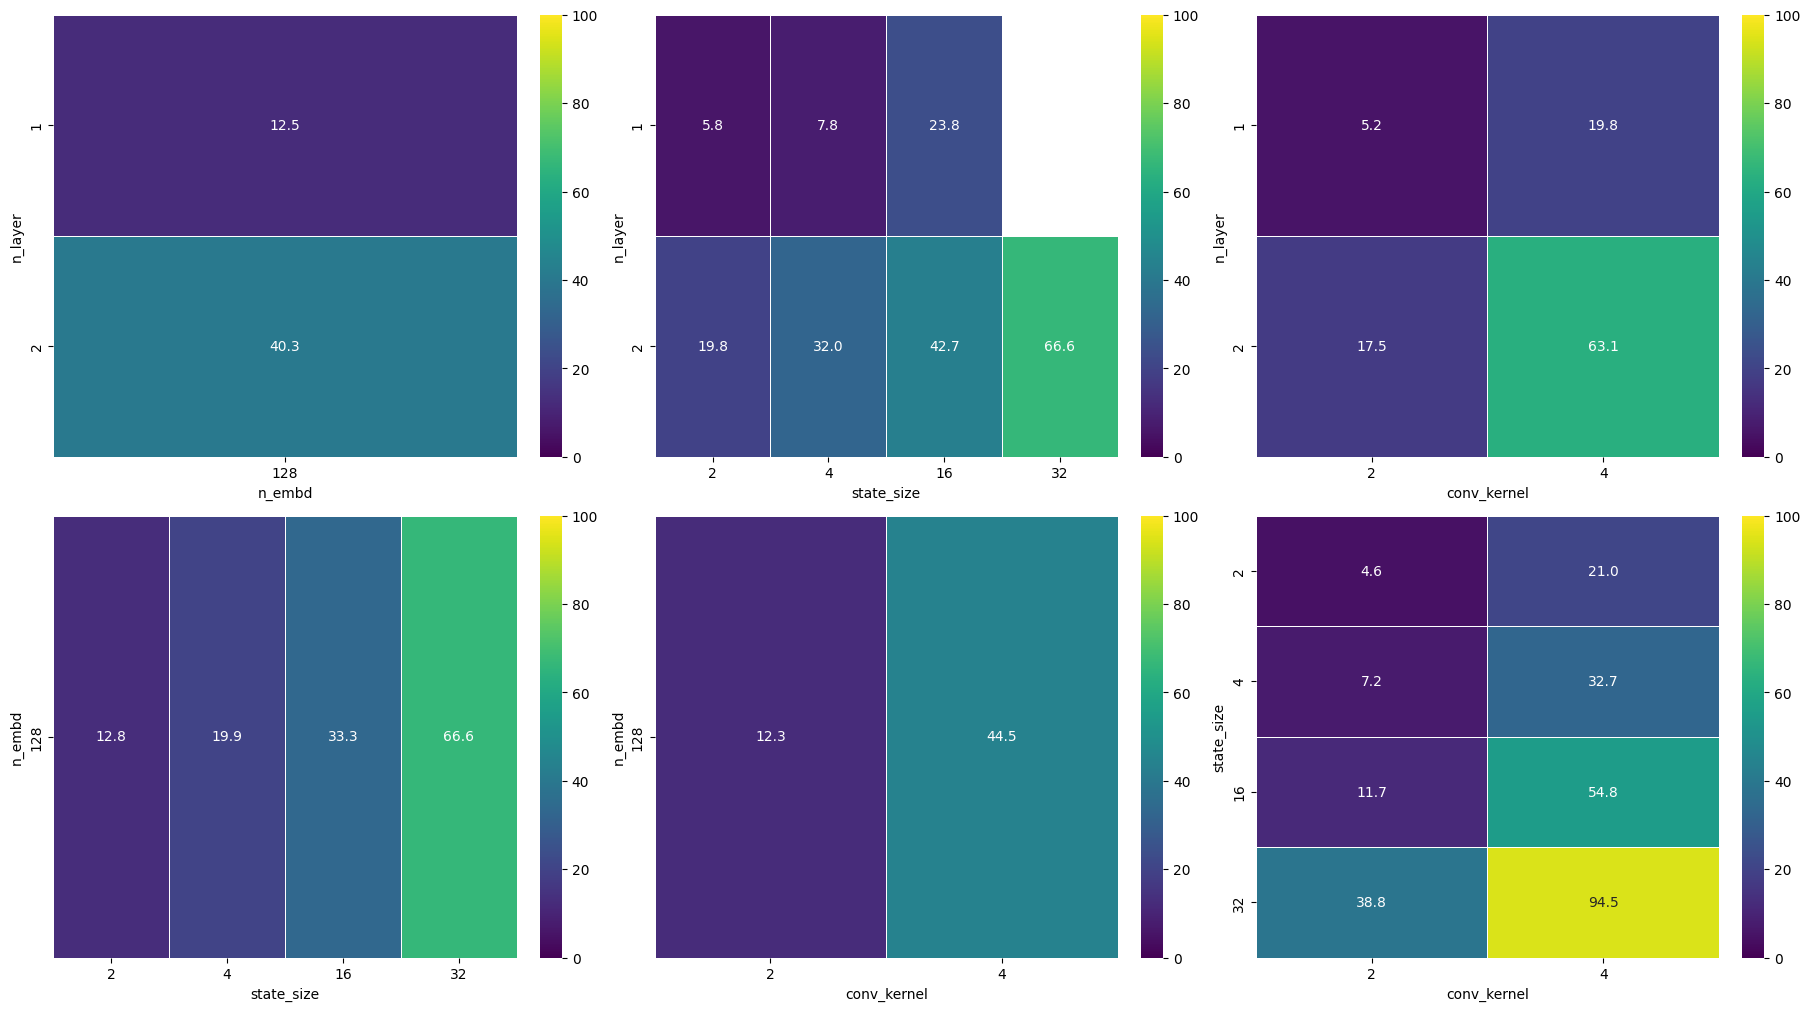

In [27]:
pairs = [
    ('n_layer', 'n_embd'),
    ('n_layer', 'state_size'),
    ('n_layer', 'conv_kernel'),
    ('n_embd', 'state_size'),
    ('n_embd', 'conv_kernel'),
    ('state_size', 'conv_kernel'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (y, x) in zip(axes.flat, pairs):
    panel_heatmap(plot_df, y, x, ax, value_col='avg_em', agg='mean')
plt.show()

In [ ]:
# import itertools
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set_theme(style="whitegrid", context="talk")

# core_params = ['n_layer', 'n_embd', 'state_size', 'conv_kernel']
# nuisance_params = ['per_device_batch_size', 'learning_rate', 'adam_beta2', 'max_steps']

# pretty = {
#     'n_layer': 'Layers',
#     'n_embd': 'Embedding dim',
#     'state_size': 'State size',
#     'conv_kernel': 'Conv kernel',
# }

# # 1) Aggregate only over repeated runs of the exact same config
# cfg_cols = ['task_name', 'n_pairs', 'base_model', *core_params, *nuisance_params]

# cfg_df = (
#     df
#     .dropna(subset=core_params + ['eval_exact_match'])
#     .assign(em_pct=lambda x: x['eval_exact_match'] * 100)
#     .groupby(cfg_cols, dropna=False)
#     .agg(
#         avg_em=('em_pct', 'mean'),
#         std_em=('em_pct', 'std'),
#         n_runs=('em_pct', 'size'),
#     )
#     .reset_index()
# )

# # Optional: focus on one model
# cfg_df = cfg_df[cfg_df['base_model'] == 'mamba2'].copy()


# def plot_pairwise_param_heatmaps(data, facet_col='n_pairs', collapse='max'):
#     pairs = list(itertools.combinations(core_params, 2))
#     facet_values = sorted(data[facet_col].dropna().unique())

#     for facet_value in facet_values:
#         sub = data[data[facet_col] == facet_value].copy()
#         if sub.empty:
#             continue

#         fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
#         fig.suptitle(
#             f"{facet_col} = {facet_value} | color = {collapse}(avg EM) over all other params",
#             fontsize=16,
#         )

#         for i, ((y, x), ax) in enumerate(zip(pairs, axes.flat)):
#             panel = (
#                 sub.groupby([y, x], dropna=False)['avg_em']
#                 .agg(collapse)  # 'max', 'mean', 'median'
#                 .unstack(x)
#                 .sort_index()
#                 .sort_index(axis=1)
#             )

#             sns.heatmap(
#                 panel,
#                 ax=ax,
#                 cmap='viridis',
#                 vmin=0,
#                 vmax=100,
#                 annot=True,
#                 fmt='.1f',
#                 linewidths=0.5,
#                 cbar=(i == len(pairs) - 1),
#             )
#             ax.set_title(f"{pretty[y]} vs {pretty[x]}")
#             ax.set_xlabel(pretty[x])
#             ax.set_ylabel(pretty[y])

#         plt.show()


# plot_pairwise_param_heatmaps(cfg_df, facet_col='n_pairs', collapse='max')

avg_em  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification           
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps       37.91   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps       99.49   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps       46.56   

                                                                   std_em  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification           
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps       27.49   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps        0.21   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps       38.78   

                                                                                                             all_ems  \
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification                                                      
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps                                          (65.4, 10.42)   
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps                                          (99.28, 99.7)   
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps      (11.94, 12.98, 94.66, 22.3, 99.84, 99.1, 63.08...   

                                                                   n_runs  
n_pairs model  layers dim  ss   ck  bs   lr    b2    modification          
8.0     mamba2 1.0    64.0 4.0  4.0 64.0 1e-03 0.999 2x steps           2  
               4.0    64.0 16.0 4.0 64.0 1e-03 0.999 2x steps           2  
NaN     NaN    NaN    NaN  NaN  NaN NaN  NaN   NaN   2x steps          32

In [52]:
list(df.model.unique())


['rmca_llama',
 'flashrnn_elman',
 'rmca-v1_llama',
 'flashrnn_slstm',
 'gated_delta_net',
 'flashrnn_gru',
 'flashrnn_lstm',
 'rmt_llama',
 'rwkv6',
 'delta_net',
 'rmca-v1.1_llama',
 'linear_attention',
 'mamba2',
 'rmca-gating_llama',
 'rmca-gating-v2_llama',
 'rmca-v2.0-write-order_llama',
 'rmca-v2.0-mem-layers-2R-2W_llama',
 'rmca-v2.0-mem-layers-1R-1W+ff_llama',
 'rmca-v2.0-mem-layers-1R-1W_llama',
 'rmca-v2.0-mem-layers-4R-4W+ff_llama',
 'rmca-v2.0-mem-layers-2R-2W+ff_llama',
 'rmca-v2.0-mem-layers-4R-4W_llama']

In [54]:
target_models = [
    'rmca-gating_llama',
    'rmca-gating-v2_llama',
    'rmca-v2.0-write-order_llama',
    'flashrnn_elman', 
    # 'flashrnn_gru', 
    # 'flashrnn_lstm', 
    'flashrnn_slstm',
    'mamba2',
    'delta_net', 'gated_delta_net',
]

filtered = grouped.reset_index()
filtered = filtered[filtered['model'].isin(target_models)]

best = (
    filtered
    .sort_values(['n_pairs', 'avg_em'], ascending=[True, False])
    .groupby(['n_pairs', 'model', 'mem'], as_index=False)
    .head(1)
    .sort_values(['n_pairs', 'model', 'mem'])
    .set_index(['n_pairs', 'model', 'mem'])
)
display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']
best[display_cols]

learning_rate  avg_em  std_em  \
n_pairs model                       mem                                  
1       flashrnn_elman              0          0.00030  100.00    0.00   
        flashrnn_slstm              0          0.00030  100.00    0.00   
        gated_delta_net             0          0.00030  100.00    0.00   
        rmca-gating-v2_llama        1          0.00100  100.00    0.00   
        rmca-gating_llama           1          0.00005  100.00    0.00   
2       flashrnn_elman              0          0.00100   50.80    0.00   
        flashrnn_slstm              0          0.00030   99.14    0.00   
        rmca-gating_llama           1          0.00100   50.97   33.85   
        rmca-v2.0-write-order_llama 2          0.00010   99.28    0.00   
                                    8          0.00010   99.18    0.00   
                                    32         0.00010   99.16    0.00   
4       delta_net                   0          0.00010   99.97    0.02   
        flashrnn_elman              0          0.00030    7.82    0.00   
        flashrnn_slstm              0          0.00030   84.42    0.00   
        gated_delta_net             0          0.00010  100.00    0.00   
        mamba2                      0          0.00030  100.00    0.00   
        rmca-gating-v2_llama        1          0.00100   23.72    0.00   
        rmca-gating_llama           1          0.00100   13.94    7.95   
        rmca-v2.0-write-order_llama 1          0.00030    7.60    0.00   
                                    2          0.00030   79.80    8.46   
                                    4          0.00030   82.26    0.00   
                                    8          0.00010   90.11    5.70   
                                    16         0.00030   95.29    1.84   
                                    32         0.00010   94.05    4.85   
8       delta_net                   0          0.00010   99.95    0.02   
        flashrnn_elman              0          0.00030    2.74    0.00   
        flashrnn_slstm              0          0.00100   32.91   28.12   
        gated_delta_net             0          0.00010   99.99    0.01   
        mamba2                      0          0.00030   99.94    0.00   
        rmca-gating_llama           1          0.00030    4.83    2.74   
        rmca-v2.0-write-order_llama 1          0.00030    0.82    0.00   
                                    2          0.00010   41.10    0.00   
                                    4          0.00030   11.30    0.00   
                                    8          0.00010   76.54   10.70   
                                    16         0.00030   35.05   24.51   
                                    32         0.00010   92.19    2.96   
16      delta_net                   0          0.00030   99.80    0.03   
        gated_delta_net             0          0.00300   99.97    0.01   
        mamba2                      0          0.00100   99.92    0.00   
        rmca-gating_llama           1          0.00010    0.82    0.36   
        rmca-v2.0-write-order_llama 2          0.00030    0.94    0.00   
                                    8          0.00030    5.44    0.00   
                                    32         0.00010   30.78   34.04   
32      delta_net                   0          0.00030   99.31    0.18   
        gated_delta_net             0          0.00100   99.93    0.01   
        mamba2                      0          0.00100   99.76    0.00   
        rmca-v2.0-write-order_llama 8          0.00010    0.34    0.08   
                                    32         0.00010    0.49    0.10   

                                                                               all_ems  \
n_pairs model                       mem                                                  
1       flashrnn_elman              0                                         (100.0,)   
        flashrnn_slstm              0                                 

In [56]:
target_models = [
    'rmca-v2.0-write-order_llama',
    'rmca-v2.0-mem-layers-2R-2W_llama',
    'rmca-v2.0-mem-layers-1R-1W+ff_llama',
    'rmca-v2.0-mem-layers-1R-1W_llama',
    'rmca-v2.0-mem-layers-4R-4W+ff_llama',
    'rmca-v2.0-mem-layers-2R-2W+ff_llama',
    'rmca-v2.0-mem-layers-4R-4W_llama'
]

filtered = grouped.reset_index()
filtered = filtered[filtered['model'].isin(target_models)]

best = (
    filtered
    .sort_values(['n_pairs', 'avg_em'], ascending=[True, False])
    .groupby(['n_pairs', 'model', 'mem'], as_index=False)
    .head(1)
    .sort_values(['n_pairs', 'model', 'mem'])
    .set_index(['n_pairs', 'model', 'mem'])
)
display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']
best.xs(8, level='n_pairs')[display_cols]

learning_rate  avg_em  std_em  \
model                               mem                                  
rmca-v2.0-mem-layers-1R-1W+ff_llama 8           0.0001   72.04    0.00   
                                    32          0.0001   12.46    0.00   
rmca-v2.0-mem-layers-1R-1W_llama    8           0.0001   86.90    0.00   
                                    32          0.0003   90.12    0.00   
rmca-v2.0-mem-layers-2R-2W+ff_llama 8           0.0003    5.40    0.00   
                                    32          0.0001   12.82    0.00   
rmca-v2.0-mem-layers-2R-2W_llama    8           0.0003    7.06    0.00   
                                    32          0.0001   79.94    0.00   
rmca-v2.0-mem-layers-4R-4W+ff_llama 8           0.0003    2.86    0.00   
                                    32          0.0003    6.36    0.00   
rmca-v2.0-mem-layers-4R-4W_llama    8           0.0003    2.66    0.00   
                                    32          0.0003   12.04    0.00   
rmca-v2.0-write-order_llama         1           0.0003    0.82    0.00   
                                    2           0.0001   41.10    0.00   
                                    4           0.0003   11.30    0.00   
                                    8           0.0001   76.54   10.70   
                                    16          0.0003   35.05   24.51   
                                    32          0.0001   92.19    2.96   

                                                       all_ems  n_runs  
model                               mem                                 
rmca-v2.0-mem-layers-1R-1W+ff_llama 8                 (72.04,)       1  
                                    32                (12.46,)       1  
rmca-v2.0-mem-layers-1R-1W_llama    8                  (86.9,)       1  
                                    32                (90.12,)       1  
rmca-v2.0-mem-layers-2R-2W+ff_llama 8                   (5.4,)       1  
                                    32                (12.82,)       1  
rmca-v2.0-mem-layers-2R-2W_llama    8                  (7.06,)       1  
                                    32                (79.94,)       1  
rmca-v2.0-mem-layers-4R-4W+ff_llama 8                  (2.86,)       1  
                                    32                 (6.36,)       1  
rmca-v2.0-mem-layers-4R-4W_llama    8                  (2.66,)       1  
                                    32                (12.04,)       1  
rmca-v2.0-write-order_llama         1                  (0.82,)       1  
                                    2                  (41.1,)       1  
                                    4                  (11.3,)       1  
                                    8    (88.58, 78.46, 62.58)       3  
                                    16    (2.64, 40.64, 61.88)       3  
                                    32   (90.62, 96.34, 89.62)       3

In [32]:
# target_models = [
#     'rmca-gating_llama',
#     'rmca-v2.0-write-order_llama',
#     'flashrnn_elman', 'flashrnn_gru', 'flashrnn_lstm', 'flashrnn_slstm',
#     'mamba2',
#     'delta_net', 'gated_delta_net',
# ]
# display_cols = ['learning_rate', 'avg_em', 'std_em', 'all_ems', 'n_runs']

# filtered = grouped.reset_index()
# filtered = filtered[filtered['model'].isin(target_models)]

# best_lr = (
#     df[df['model'].isin(target_models)]
#     .sort_values(['n_pairs', 'eval_exact_match'], ascending=[True, False])
#     .groupby(['n_pairs', 'model', 'mem'], as_index=False)
#     .first()[['n_pairs', 'model', 'mem', 'learning_rate']]
# )

# best = filtered.merge(best_lr, on=['n_pairs', 'model', 'mem', 'learning_rate'])
# best = best.sort_values(['n_pairs', 'model', 'mem']).set_index(['n_pairs', 'model', 'mem'])
# best[display_cols]

In [11]:
# Select only the best row for each (task_name, model), corresponding to the best memory size, learning rate, and modification, ranked by avg_em
best_rows = grouped.reset_index().sort_values(['n_pairs', 'avg_em'], ascending=[True, False]).groupby(['n_pairs', 'model'], as_index=False).head(1)
# best_rows

In [12]:
best_rows[best_rows.n_pairs == 16]

,n_pairs,model,mem,learning_rate,modification,avg_em,std_em,all_ems,n_runs
161,16,gated_delta_net,0,0.0030,,99.97,0.01,"(99.98, 99.96, 99.98)",3
167,16,mamba2,0,0.0010,,99.92,0.00,"(99.92,)",1
155,16,delta_net,0,0.0003,,99.80,0.03,"(99.8, 99.84, 99.76)",3
174,16,rwkv6,0,0.0003,,86.17,4.42,"(88.3, 90.2, 80.02)",3
171,16,rmca-v2.0-write-order_llama,32,0.0001,2x steps,30.78,34.04,"(78.92, 6.66, 6.76)",3
168,16,rmca-v1.1_llama,8,0.0010,,0.50,0.00,"(0.5,)",1
164,16,linear_attention,0,0.0010,,0.04,0.03,"(0.02, 0.02, 0.08)",3


In [13]:
# group_cols = ['task_name', 'model', 'mem', 'segment', 'learning_rate']
group_cols = ['task_name', 'model', 'mem', 'learning_rate', 'modification']

grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
)

grouped.sort_values(['task_name', 'avg_em'], ascending=[True, False])

avg_em  \
task_name       model                       mem learning_rate modification           
N1-K2V2-V62_1M  flashrnn_elman              0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_gru                0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_lstm               0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                flashrnn_slstm              0   0.000300      2x steps      100.00   
                                                0.001000      2x steps      100.00   
                gated_delta_net             0   0.000300                    100.00   
                                                0.001000                    100.00   
                rmca-v1_llama               8   0.000300                    100.00   
                rmca_llama                  8   0.000300                    100.00   
                                                0.001000                    100.00   
                rmca-v1_llama               8   0.001000                     99.82   
N16-K2V2-V62_1M gated_delta_net             0   0.003000                     99.97   
                                                0.000100                     99.95   
                                                0.000300                     99.94   
                                                0.001000                     99.93   
                mamba2                      0   0.001000                     99.92   
                                                0.000300                     99.84   
                delta_net                   0   0.000300                     99.80   
                                                0.000100                     99.69   
                                                0.001000                     99.61   
                                                0.003000                     99.33   
                rwkv6                       0   0.000300                     86.17   
                                                0.000100                     50.05   
                rmca-v2.0-write-order_llama 32  0.000100      2x steps       30.78   
                                                0.000300      2x steps        3.65   
                                            8   0.000100      2x steps        2.50   
                                                0.000300      2x steps        0.54   
                rmca-v1.1_llama             8   0.001000                      0.50   
                rwkv6                       0   0.001000                      0.06   
                linear_attention            0   0.001000                      0.04   
                rwkv6                       0   0.003000                      0.04   
                linear_attention            0   0.000100                      0.01   
                                                0.000300                      0.01   
                                                0.003000                      0.01   
N2-K2V2-V62_1M  flashrnn_slstm              0   0.000300      2x steps       99.14   
                rmca_llama                  8   0.000300                     98.98   
                                                0.001000                     94.84   
                rmca-v1.1_llama             8   0.001000                     94.74   
                flashrnn_slstm              0   0.001000      2x steps       51.84   
                flashrnn_gru                0   0.000300      2x steps       51.82   
                flashrnn_lstm               0   0.001000      2x steps       51.30   
                flashrnn_gru                0   0.001000      2x steps       51.22   
                flashrnn_elman    

In [15]:
df['model']

,model,model
0,rmca_llama,rmca_llama
1,flashrnn_elman,flashrnn_elman
2,rmca-v1_llama,rmca-v1_llama
3,flashrnn_slstm,flashrnn_slstm
4,rmca-v1_llama,rmca-v1_llama
...,...,...
376,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
377,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
378,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama
379,rmca-v2.0-write-order_llama,rmca-v2.0-write-order_llama


In [ ]:
group_cols = ['task_name', 'model', 'mem', 'segment', 'learning_rate']

grouped = df.groupby(group_cols, dropna=False).agg(
    avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs=('eval_exact_match', 'count'),
).reset_index()

pivot = grouped.pivot_table(
    index=['model', 'mem', 'segment', 'learning_rate'],
    columns='task_name',
    values='avg_em',
)
pivot.sort_index()

task_name                                               N1-K2V2-V62_1M  \
model                       mem  segment learning_rate                   
rmca-v1.1_llama             4.0  1x4     0.000300                  NaN   
                            8.0  1x16    0.001000                  NaN   
                                 1x2     0.001000                  NaN   
                                 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x8     0.001000                  NaN   
                            32.0 1x4     0.000300                  NaN   
rmca-v1_llama               8.0  1x1     0.000300               100.00   
                                         0.001000                99.82   
rmca-v2.0-write-order_llama 1.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            2.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            4.0  1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            8.0  1x4     0.000001                  NaN   
                                         0.000003                  NaN   
                                         0.000010                  NaN   
                                         0.000030                  NaN   
                                         0.000100                  NaN   
                                         0.000300                  NaN   
                                 1x8     0.000001                  NaN   
                                         0.000003                  NaN   
                                         0.000010                  NaN   
                                         0.000030                  NaN   
                                         0.000100                  NaN   
                                         0.000300                  NaN   
                                         0.001000                  NaN   
                                         0.003000                  NaN   
                            16.0 1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
                            32.0 1x4     0.000300                  NaN   
                                 1x8     0.000300                  NaN   
rmca_llama                  1.0  1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                                         0.001000                  NaN   
                            2.0  1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                            8.0  1x1     0.000300               100.00   
                                         0.001000               100.00   
                                 1x2     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
                                 1x8     0.000300                  NaN   
                                         0.001000                  NaN   
                                 8x1     0.000300                  NaN   
                                         0.001000                  NaN   
                            16.0 1x4     0.000300                  NaN   
                                         0.001000                  NaN   
    

In [ ]:
# # group_cols = ['model', 'mem', 'task_name', 'n_pairs', 'learning_rate']
# group_cols = ['task_name', 'model', 'mem', 'learning_rate']

# grouped = df.groupby(group_cols, dropna=False).agg(
#     avg_em=('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
#     std_em=('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
#     all_ems=('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
#     n_runs=('eval_exact_match', 'count'),
# )

# grouped.sort_values(['model', 'mem', 'avg_em'], ascending=[True, True, False])

avg_em  \
task_name       model                       mem  learning_rate           
N4-K2V2-V62_1M  delta_net                   0.0  0.000100        99.97   
                                                 0.003000        99.96   
                                                 0.001000        99.95   
N8-K2V2-V62_1M  delta_net                   0.0  0.000100        99.95   
N4-K2V2-V62_1M  delta_net                   0.0  0.000300        99.94   
N8-K2V2-V62_1M  delta_net                   0.0  0.000300        99.94   
                                                 0.003000        99.86   
                                                 0.001000        99.85   
N16-K2V2-V62_1M delta_net                   0.0  0.000300        99.80   
                                                 0.000100        99.69   
                                                 0.001000        99.61   
                                                 0.003000        99.33   
N32-K2V2-V62_1M delta_net                   0.0  0.000300        99.31   
                                                 0.001000        98.39   
                                                 0.000100        98.12   
                                                 0.003000        98.11   
N1-K2V2-V62_1M  flashrnn_elman              0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_elman              0.0  0.001000        50.80   
                                                 0.000300        48.42   
N4-K2V2-V62_1M  flashrnn_elman              0.0  0.000300         7.82   
                                                 0.001000         5.72   
N8-K2V2-V62_1M  flashrnn_elman              0.0  0.000300         2.74   
                                                 0.001000         1.61   
N1-K2V2-V62_1M  flashrnn_gru                0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_gru                0.0  0.000300        51.82   
                                                 0.001000        51.22   
N4-K2V2-V62_1M  flashrnn_gru                0.0  0.000300        24.96   
                                                 0.001000        23.68   
N8-K2V2-V62_1M  flashrnn_gru                0.0  0.001000         7.74   
                                                 0.000300         2.94   
N1-K2V2-V62_1M  flashrnn_lstm               0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000        51.30   
                                                 0.000300        50.68   
N4-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000        23.26   
                                                 0.000300        22.62   
N8-K2V2-V62_1M  flashrnn_lstm               0.0  0.001000         9.90   
                                                 0.000300         3.70   
                                                 0.010000         0.02   
N1-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300       100.00   
                                                 0.001000       100.00   
N2-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        99.14   
N4-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        84.42   
N2-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        51.84   
N8-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        32.91   
N4-K2V2-V62_1M  flashrnn_slstm              0.0  0.001000        25.92   
N8-K2V2-V62_1M  flashrnn_slstm              0.0  0.000300        14.44   
N1-K2V2-V62_1M  gated_delta_net             0.0  0.000300       100.00   
                                                 0.001000       100.00   
N4-K2V2-V62_1M  gated_delta_net             0.0  0.000100       100.00   
                                                 0.000300       100.